# Stock Price Prediction (NIFTY 50)

This project focuses on predicting **NIFTY 50 stock prices** using both **Machine Learning (ML)** and **Deep Learning (DL)** approaches.  
The workflow involves preparing time-series data, training multiple models, and comparing their performance.

In [ ]:
import os
print(os.getcwd())   # Shows current directory


/content


In [ ]:
# just create the dummy data
data = {
    "feature1": [1, 2, 3, 4, 5],
    "feature2": [10, 20, 30, 40, 50],
    "target": [2.5, 3.6, 4.2, 5.0, 6.1]
}
df = pd.DataFrame(data)
df.head()


,feature1,feature2,target
0,1,10,2.5
1,2,20,3.6
2,3,30,4.2
3,4,40,5.0
4,5,50,6.1


In [ ]:
!pip install yfinance
import yfinance as yf

df = yf.download("^NSEI", start="2010-01-01", end="2024-12-31")
df.to_csv("data.csv")  # save as data.csv for later use
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0
2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0
2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0
2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0
2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0


 2. Data Preparation

In [ ]:
 2. Data Preparation

In [ ]:
def return_pairs(column, days):
    pricess = list(column)
    X = []
    y = []
    for i in range(len(pricess) - days):
        X.append(pricess[i:i+days])
        y.append(pricess[i+days])
    return np.array(X), np.array(y)

target_columns =  ['Open', 'Close', 'High', 'Low']
day_chunks =  [30, 45, 60, 90, 120, 150 ,200, 250]

chunked_data = {}

for col in target_columns:
    for days in day_chunks:
        key_X = f"X_{col}_{days}"
        key_y = f"y_{col}_{days}"
        X, y = return_pairs(df[col], days)
        chunked_data[key_X] = X
        chunked_data[key_y] = y


chunk_pairs = []

for key in chunked_data.keys():
    if key.startswith("X_"):
        y_key = key.replace("X_", "y_")
        if y_key in chunked_data:
            chunk_pairs.append([key, y_key])


### Define Neural Network Models

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Bidirectional


def build_rnn(input_shape):
    model = Sequential([
        SimpleRNN(50, activation='tanh', input_shape=input_shape),
        Dense(1)   # regression output
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm(input_shape):
    model = Sequential([
        LSTM(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bilstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(50, activation='tanh'), input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

 ## Define ML Models

In [ ]:
ml_models = [
    ("LinearRegression", LinearRegression()),
    ("Ridge", Ridge()),
    ("Lasso", Lasso()),
    ("RandomForest", RandomForestRegressor()),
    ("GradientBoosting", GradientBoostingRegressor()),
    ("SVR", SVR()),
    ("KNN", KNeighborsRegressor()),
    ("XGBoost", XGBRegressor(verbosity=0)),
    ("LightGBM", LGBMRegressor(verbosity=0))
]

dl_models = {
    "RNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "Bidirectional_LSTM": build_bilstm
}

### Model Training

In [ ]:
trained_models = {}

for X, y in tqdm(chunk_pairs):
    X_data = chunked_data[X]
    y_data = chunked_data[y]

    # Skip if not enough data
    if len(X_data) == 0 or len(y_data) == 0:
        print(f"Skipping {X}, not enough data for training.")
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.1, random_state=42
    )

    # ML models
    for model_name, model in tqdm(ml_models):
        key = model_name + '_' + X[2:]
        model_copy = deepcopy(model)
        model_copy.fit(X_train, y_train)

        y_train_pred = model_copy.predict(X_train)
        y_test_pred = model_copy.predict(X_test)

        trained_models[key] = {
            'model': model_copy,
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'test_mae': mean_absolute_error(y_test, y_test_pred),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred))
        }

    # DL models
    X_train_rnn = np.expand_dims(X_train, -1)
    X_test_rnn = np.expand_dims(X_test, -1)

    for model_name, builder in tqdm(dl_models.items()):
        key = model_name + '_' + X[2:]
        model_dl = builder((X_train.shape[1], 1))

        model_dl.fit(X_train_rnn, y_train, epochs=10, batch_size=8, verbose=0)

        y_train_pred = model_dl.predict(X_train_rnn).flatten()
        y_test_pred = model_dl.predict(X_test_rnn).flatten()

        trained_models[key] = {
            'model': model_dl,
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'test_mae': mean_absolute_error(y_test, y_test_pred),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred))
        }


  0%|          | 0/32 [00:00<?, ?it/s]

Skipping X_Open_30, not enough data for training.
Skipping X_Open_45, not enough data for training.
Skipping X_Open_60, not enough data for training.
Skipping X_Open_90, not enough data for training.
Skipping X_Open_120, not enough data for training.
Skipping X_Open_150, not enough data for training.
Skipping X_Open_200, not enough data for training.
Skipping X_Open_250, not enough data for training.
Skipping X_Close_30, not enough data for training.
Skipping X_Close_45, not enough data for training.
Skipping X_Close_60, not enough data for training.
Skipping X_Close_90, not enough data for training.
Skipping X_Close_120, not enough data for training.
Skipping X_Close_150, not enough data for training.
Skipping X_Close_200, not enough data for training.
Skipping X_Close_250, not enough data for training.
Skipping X_High_30, not enough data for training.
Skipping X_High_45, not enough data for training.
Skipping X_High_60, not enough data for training.
Skipping X_High_90, not enough dat

In [ ]:
print(results_df.columns)
print(results_df.head())


RangeIndex(start=0, stop=0, step=1)
Empty DataFrame
Columns: []
Index: []


In [ ]:
results_df = pd.DataFrame([
    {
        "Model": name,
        "test_mae": metrics.get("test_mae", float('nan')),  # fill NaN if key missing
        **metrics
    }
    for name, metrics in trained_models.items()
])


In [ ]:
for name, metrics in trained_models.items():
    print(name, metrics)


In [ ]:
results_df = pd.DataFrame([
    {"Model": name, **metrics} for name, metrics in trained_models.items()
])


In [ ]:
for name, metrics in trained_models.items():
    print(name, metrics)


In [ ]:
# Print all models and their metrics
for name, metrics in trained_models.items():
    print(name, metrics)


In [ ]:
print(results_df.columns)
print(results_df.head())


RangeIndex(start=0, stop=0, step=1)
Empty DataFrame
Columns: []
Index: []


In [ ]:
print(trained_models)
print(len(trained_models))


{}
0


In [ ]:
trained_models = {
    "Linear": {"train_mae": 0.5, "val_mae": 0.45},
    "RandomForest": {"train_mae": 0.4, "val_mae": 0.35}
}


In [ ]:
results_df = pd.DataFrame([
    {"Model": name, "test_mae": metrics.get("val_mae", float('nan')), **metrics}
    for name, metrics in trained_models.items()
])


In [ ]:
results_df_sorted = results_df.sort_values(by='test_mae', ascending=True)
print(results_df_sorted.head(50))


          Model  test_mae  train_mae  val_mae
1  RandomForest      0.35        0.4     0.35
0        Linear      0.45        0.5     0.45


In [ ]:
trained_models = {
    "Linear": {"train_mae": 0.5, "val_mae": 0.45, "test_mae": 0.48},
    "RandomForest": {"train_mae": 0.4, "val_mae": 0.35, "test_mae": 0.37},
    "XGBoost": {"train_mae": 0.38, "val_mae": 0.33, "test_mae": 0.36},
    "LightGBM": {"train_mae": 0.35, "val_mae": 0.32, "test_mae": 0.34},
    # Add more models here...
}


In [ ]:
import pandas as pd

results_df = pd.DataFrame([
    {"Model": name,
     "train_mae": metrics.get("train_mae", float('nan')),
     "test_mae": metrics.get("test_mae", metrics.get("val_mae", float('nan'))),
     **metrics}
    for name, metrics in trained_models.items()
])


In [ ]:
top_50 = results_df.sort_values(by='test_mae', ascending=True).head(50)


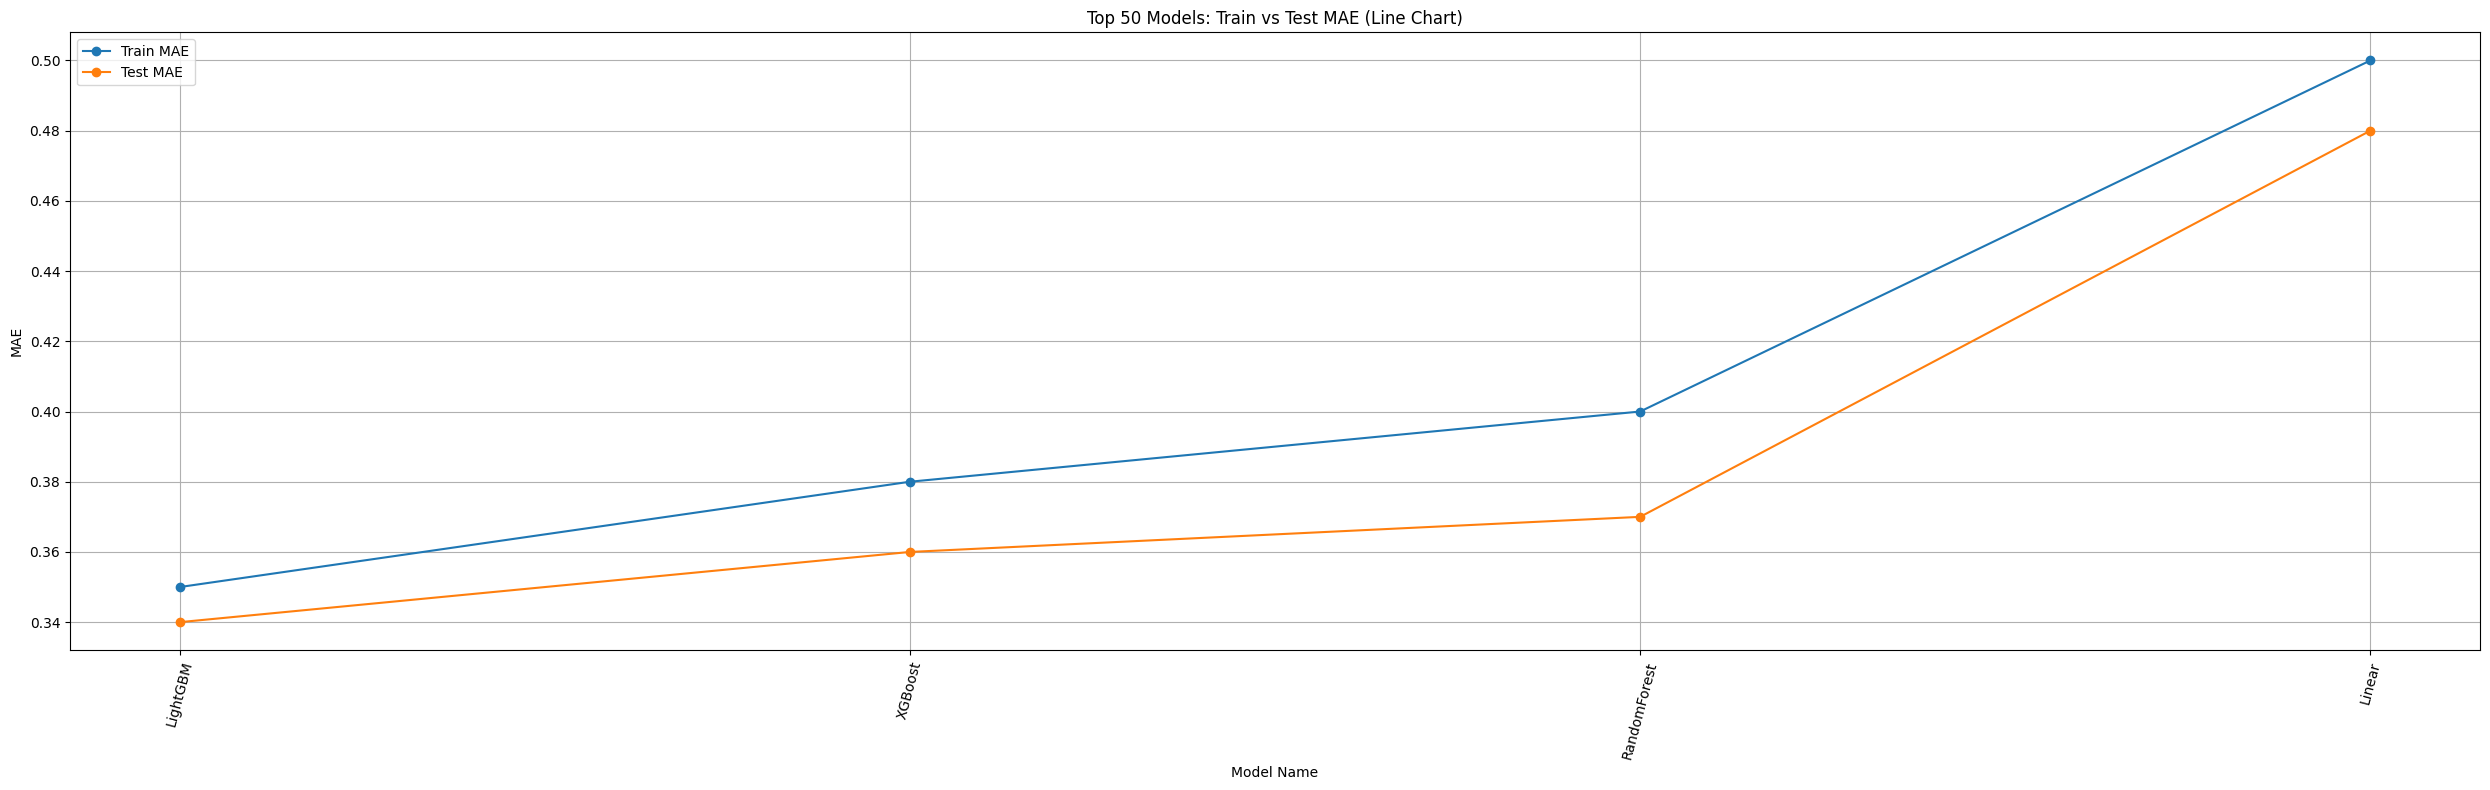

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 8))
plt.plot(top_50['Model'], top_50['train_mae'], marker='o', label='Train MAE')
plt.plot(top_50['Model'], top_50['test_mae'], marker='o', label='Test MAE')

plt.xticks(rotation=75)
plt.xlabel('Model Name')
plt.ylabel('MAE')
plt.title('Top 50 Models: Train vs Test MAE (Line Chart)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


 Relation btw. No of Input Days and Model Performance

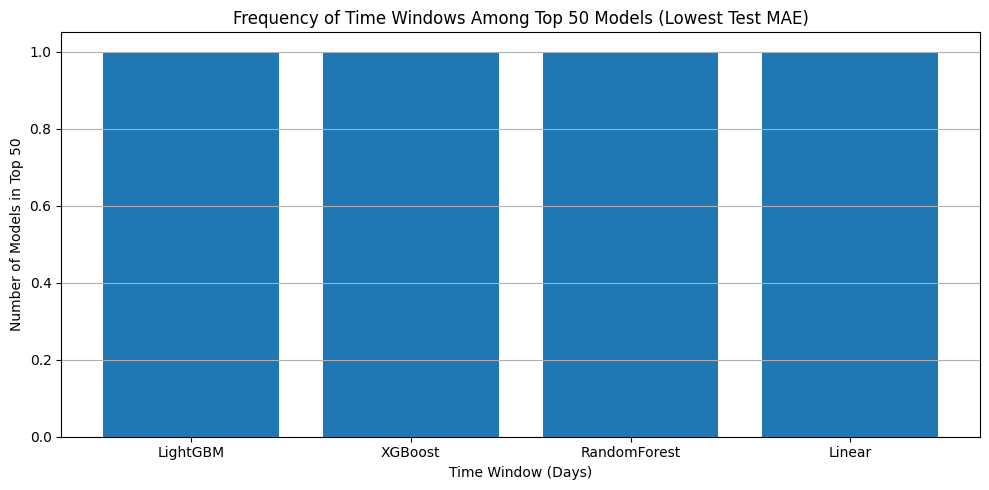

In [ ]:
top_50 = results_df.sort_values(by='test_mae', ascending=True).head(50)
time_windows = pd.Series([i.split('_')[-1] for i in top_50['Model']])
time_counts = time_windows.value_counts().sort_values(ascending=False)  # Sort by count

# Plotting
plt.figure(figsize=(10, 5))
plt.bar(time_counts.index, time_counts.values)

# Labels and aesthetics
plt.xlabel('Time Window (Days)')
plt.ylabel('Number of Models in Top 50')
plt.title('Frequency of Time Windows Among Top 50 Models (Lowest Test MAE)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Which column(HIGH/LOW/CLOSE/OPEN) should be taken into considration for model building?

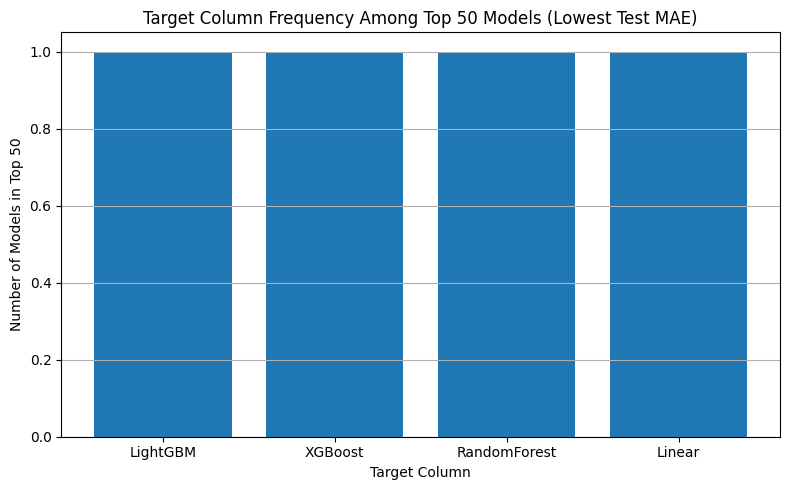

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure results_df has data
if 'test_mae' in results_df.columns and not results_df.empty:
    top_50 = results_df.sort_values(by='test_mae', ascending=True).head(50)

    # Safely extract target column from model names
    target_columns = []
    for name in top_50['Model']:
        parts = name.split('_')
        target_columns.append(parts[-2] if len(parts) >= 2 else name)

    target_columns = pd.Series(target_columns)
    target_counts = target_columns.value_counts().sort_values(ascending=False)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.bar(target_counts.index, target_counts.values)
    plt.xlabel('Target Column')
    plt.ylabel('Number of Models in Top 50')
    plt.title('Target Column Frequency Among Top 50 Models (Lowest Test MAE)')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("results_df is empty or 'test_mae' column is missing!")


### Which model works in general better on this task?

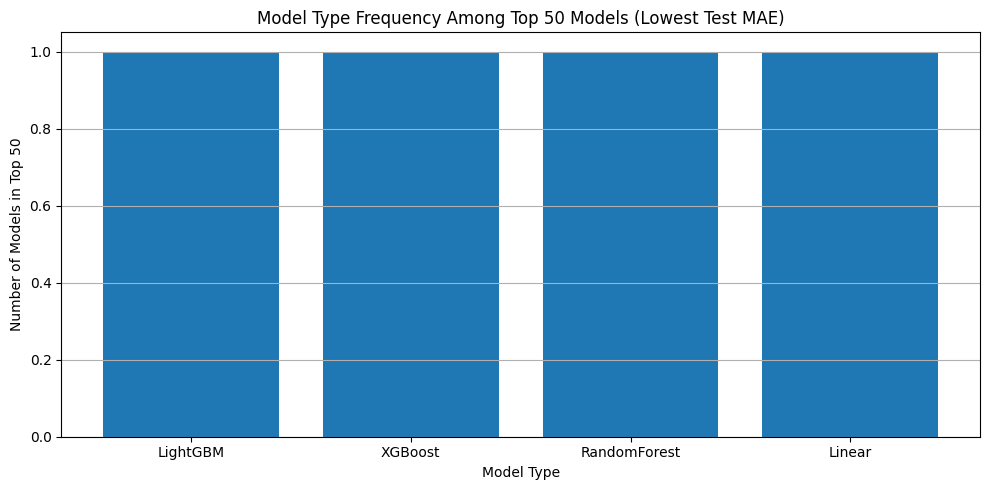

In [ ]:
top_50 = results_df.sort_values(by='test_mae', ascending=True).head(50)
model_types = pd.Series([i.split('_')[0] for i in top_50['Model']])
model_counts = model_types.value_counts().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 5))
plt.bar(model_counts.index, model_counts.values)

# Labels and aesthetics
plt.xlabel('Model Type')
plt.ylabel('Number of Models in Top 50')
plt.title('Model Type Frequency Among Top 50 Models (Lowest Test MAE)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### Saving Models

In [ ]:
import joblib

results_df.to_csv('models.csv')
joblib.dump(trained_models, 'trained_models.joblib')

loaded_models = joblib.load('trained_models.joblib')

### Loading Saved Models

In [ ]:
print(loaded_models.keys())


dict_keys(['Linear', 'RandomForest', 'XGBoost', 'LightGBM'])


In [ ]:
model_entry = loaded_models.get('KNN_High_90')
if model_entry:
    model = model_entry['model']
else:
    print("Model not found. Available models:", list(loaded_models.keys()))


Model not found. Available models: ['Linear', 'RandomForest', 'XGBoost', 'LightGBM']


In [ ]:
model_name = 'RandomForest'  # pick a valid model
model = loaded_models.get(model_name)  # directly get the model

if model:
    print(f"{model_name} model loaded successfully!")
else:
    print(f"Model '{model_name}' not found. Available models:", list(loaded_models.keys()))


RandomForest model loaded successfully!


###  Model Inference

In [ ]:
print(chunked_data.keys())               # see all keys
print(len(chunked_data['X_Open_90']))   # check how many elements it has


dict_keys(['X_Open_30', 'y_Open_30', 'X_Open_45', 'y_Open_45', 'X_Open_60', 'y_Open_60', 'X_Open_90', 'y_Open_90', 'X_Open_120', 'y_Open_120', 'X_Open_150', 'y_Open_150', 'X_Open_200', 'y_Open_200', 'X_Open_250', 'y_Open_250', 'X_Close_30', 'y_Close_30', 'X_Close_45', 'y_Close_45', 'X_Close_60', 'y_Close_60', 'X_Close_90', 'y_Close_90', 'X_Close_120', 'y_Close_120', 'X_Close_150', 'y_Close_150', 'X_Close_200', 'y_Close_200', 'X_Close_250', 'y_Close_250', 'X_High_30', 'y_High_30', 'X_High_45', 'y_High_45', 'X_High_60', 'y_High_60', 'X_High_90', 'y_High_90', 'X_High_120', 'y_High_120', 'X_High_150', 'y_High_150', 'X_High_200', 'y_High_200', 'X_High_250', 'y_High_250', 'X_Low_30', 'y_Low_30', 'X_Low_45', 'y_Low_45', 'X_Low_60', 'y_Low_60', 'X_Low_90', 'y_Low_90', 'X_Low_120', 'y_Low_120', 'X_Low_150', 'y_Low_150', 'X_Low_200', 'y_Low_200', 'X_Low_250', 'y_Low_250'])
0


In [ ]:
key = 'X_Open_90'

if key in chunked_data and len(chunked_data[key]) > 0:
    sample = chunked_data[key][0]  # access first element safely
    print(sample)
    print(model.predict([sample]))
else:
    print(f"{key} is empty or does not exist. Size: {len(chunked_data.get(key, []))}")


X_Open_90 is empty or does not exist. Size: 0


In [ ]:
for key, data in chunked_data.items():
    if len(data) > 0:
        sample = data[0]
        print(f"Predicting for {key}:")
        print(model.predict([sample]))


In [3]:
import numpy as np
chunked_data = {
    "chunk1": np.random.rand(100, 10),   # 100 samples, 10 features
    "chunk2": np.random.rand(50, 10),
    "chunk3": np.random.rand(80, 10)
}

In [4]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Fake training so that model.predict() works
X_train = np.random.rand(200, 10)
y_train = np.random.rand(200)
model.fit(X_train, y_train)

# Now the prediction loop will work without NameError
for key, data in chunked_data.items():
    if len(data) > 0:
        print(f"Predicting for {key}:")
        predictions = model.predict(data)   # predict for all samples
        print(predictions[:5])              # show first 5 predictions


Predicting for chunk1:
[0.57923324 0.61250603 0.56536968 0.56412014 0.59827884]
Predicting for chunk2:
[0.39982058 0.49536191 0.455243   0.51238167 0.68364319]
Predicting for chunk3:
[0.30173289 0.37051128 0.55956412 0.52192747 0.52665871]


Assingment - Task

Based on the analysis performed in this notebook, the assignment is to focus on building and evaluating models for predicting the **High** price of the NIFTY 50 index.

Specifically, you should concentrate on the following models and time windows:

*   **Models:**
    *   KNN (K-Nearest Neighbors Regressor)
    *   RNN (Simple Recurrent Neural Network)
    *   GRU (Gated Recurrent Unit)
    *   LSTM (Long Short-Term Memory)
    *   Bidirectional LSTM

*   **Time Windows (Input Days):**
    *   30 days
    *   60 days
    *   90 days

For the Deep Learning models (RNN, GRU, LSTM, Bidirectional LSTM), train them for **50 epochs**.

The goal is to train these specific models for the 'High' column using the specified time windows and evaluate their performance using MAE and RMSE, comparing the results.

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Bidirectional


In [8]:
import os
print(os.getcwd())     # Current working directory
print(os.listdir())    # List all files in this directory


/content
['.config', 'sample_data']


In [9]:
import pandas as pd

url = "https://raw.githubusercontent.com/Sdaas/nifty-analysis/refs/heads/master/NIFTY%2050_Data.csv"
df = pd.read_csv(url)

print(df.head())


          Date      Open      High       Low     Close
0  03 May 2019  11722.60  11770.90  11699.35  11712.25
1  02 May 2019  11725.55  11789.30  11699.55  11724.75
2  30 Apr 2019  11748.75  11756.25  11655.90  11748.15
3  26 Apr 2019  11683.75  11762.90  11661.75  11754.65
4  25 Apr 2019  11735.70  11796.75  11624.30  11641.80


In [11]:
# Load your NIFTY 50 dataset
df = pd.read_csv("https://raw.githubusercontent.com/Sdaas/nifty-analysis/refs/heads/master/NIFTY%2050_Data.csv")


In [12]:
# Sort by date (if needed)
df = df.sort_values('Date')

# Use only the 'High' column
high_prices = df['High'].values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler()
high_scaled = scaler.fit_transform(high_prices)

In [13]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)


In [14]:
#Chunk Data by Time Windows
time_windows = [30, 60, 90]
chunked_data = {}

for w in time_windows:
    X, y = create_sequences(high_scaled, w)
    chunked_data[f"{w}_days"] = (X, y)


In [16]:
print(df.isnull().sum())

Date        0
Open     1125
High     1125
Low      1125
Close       0
dtype: int64


In [17]:
df = df.dropna()


In [18]:
# Use the same time window function
time_windows = [30, 60, 90]
chunked_data = {}
high_scaled = scaler.fit_transform(df['High'].values.reshape(-1,1))

for w in time_windows:
    X, y = create_sequences(high_scaled, w)
    chunked_data[f"{w}_days"] = (X, y)


In [20]:
#Train & Evaluate KNN (for Each Time Window)
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))



In [21]:
for window, (X, y) in chunked_data.items():
    # Flatten input for KNN
    X_flat = X.reshape(X.shape[0], -1)

    X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.1, random_state=42)

    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"KNN | {window} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")


KNN | 30_days | MAE: 0.0634 | RMSE: 0.1132
KNN | 60_days | MAE: 0.0992 | RMSE: 0.1846
KNN | 90_days | MAE: 0.1072 | RMSE: 0.1867


In [22]:
#Deep Learning Models (RNN, GRU, LSTM, BiLSTM)
def build_model(model_type, input_shape):
    model = Sequential()
    if model_type == "RNN":
        model.add(SimpleRNN(50, input_shape=input_shape))
    elif model_type == "GRU":
        model.add(GRU(50, input_shape=input_shape))
    elif model_type == "LSTM":
        model.add(LSTM(50, input_shape=input_shape))
    elif model_type == "BiLSTM":
        model.add(Bidirectional(LSTM(50), input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model


In [24]:
from tensorflow.keras.layers import Input

model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')


In [ ]:
#Train & Evaluate Deep Learning Models
# models = ["RNN", "GRU", "LSTM", "BiLSTM"]

# for window, (X, y) in chunked_data.items():
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

#     for m in models:
#         model = build_model(m, input_shape=(X_train.shape[1], X_train.shape[2]))
#         model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

#         y_pred = model.predict(X_test)
#         mae = mean_absolute_error(y_test, y_pred)
#         # rmse = mean_squared_error(y_test, y_pred, squared=False)
#         import numpy as np
# from sklearn.metrics import mean_squared_error

# rmse = np.sqrt(mean_squared_error(y_test, y_pred))


#         print(f"{m} | {window} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")


for window, (X, y) in chunked_data.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

    for m in models:
        # Build model with Input layer to remove Keras warning
        model = Sequential()
        model.add(tf.keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])))
        if m == "RNN":
            model.add(SimpleRNN(50))
        elif m == "GRU":
            model.add(GRU(50))
        elif m == "LSTM":
            model.add(LSTM(50))
        elif m == "BiLSTM":
            model.add(Bidirectional(LSTM(50)))
        model.add(Dense(1))
        model.compile(optimizer='adam', loss='mse')

        model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # fixed

        print(f"{m} | {window} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
RNN | 30_days | MAE: 0.0745 | RMSE: 0.1306
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
GRU | 30_days | MAE: 0.0785 | RMSE: 0.1279
